In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# STEP 1: GET WEATHER DATA
# -----------------------------

latitude = 34.0522
longitude = -118.2437

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": "2024-01-01",
    "end_date": "2024-12-31",
    "daily": "temperature_2m_max",
    "timezone": "America/Los_Angeles"
}

response = requests.get(url, params=params)
data = response.json()

df = pd.DataFrame(data["daily"])
df

,time,temperature_2m_max
0,2024-01-01,17.3
1,2024-01-02,17.2
2,2024-01-03,16.0
3,2024-01-04,15.2
4,2024-01-05,15.9
...,...,...
361,2024-12-27,16.1
362,2024-12-28,17.5
363,2024-12-29,18.1
364,2024-12-30,19.2


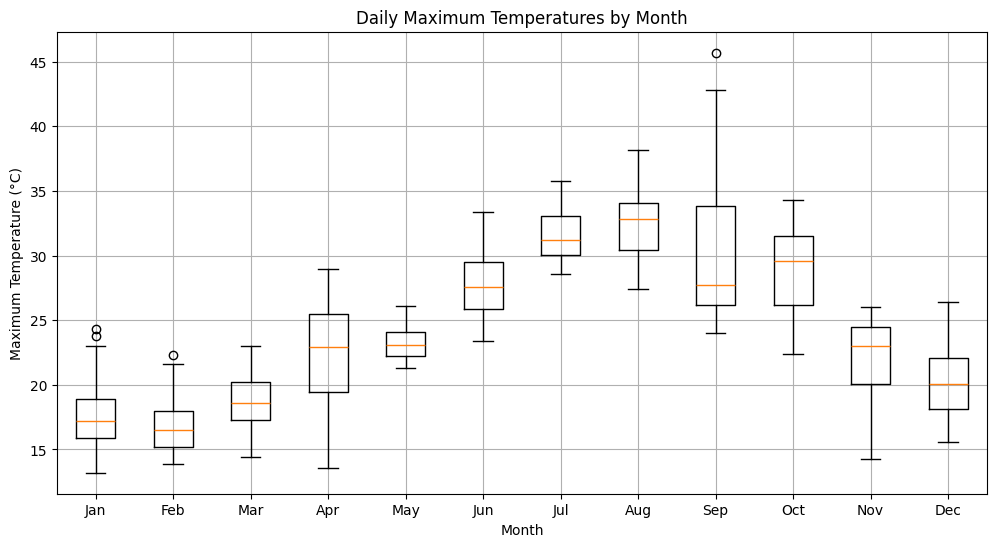

In [2]:
# -----------------------------
# STEP 2: PREPARE MONTH DATA
# -----------------------------

df["time"] = pd.to_datetime(df["time"])

df["month"] = df["time"].dt.month_name()

# Create data grouped by month
monthly_temps = [
    df[df["month"] == month]["temperature_2m_max"]
    for month in [
        "January", "February", "March", "April",
        "May", "June", "July", "August",
        "September", "October", "November", "December"
    ]
]

# -----------------------------
# STEP 3: BOXPLOT
# -----------------------------

plt.figure(figsize=(12, 6))

plt.boxplot(monthly_temps,
            tick_labels=[
                "Jan", "Feb", "Mar", "Apr",
                "May", "Jun", "Jul", "Aug",
                "Sep", "Oct", "Nov", "Dec"
            ])

plt.xlabel("Month")
plt.ylabel("Maximum Temperature (°C)")
plt.title("Daily Maximum Temperatures by Month")

plt.grid(True)

plt.show()

In [3]:
# -----------------------------
# STEP 2: CREATE GROUPS
# -----------------------------

df["time"] = pd.to_datetime(df["time"])
df["month"] = df["time"].dt.month

# February vs April temperatures
mo1 = 11
mo2 = 12


mo1 = 2
mo2 = 3
mo1 = 7
mo2 = 8

month1text = pd.to_datetime(f"2026-{mo1:02d}-01").strftime("%B")
month2text = pd.to_datetime(f"2026-{mo2:02d}-01").strftime("%B")
month1 = df[df["month"] == mo1]["temperature_2m_max"].values
month2 = df[df["month"] == mo2]["temperature_2m_max"].values

# -----------------------------
# STEP 3: OBSERVED DIFFERENCE
# -----------------------------



# -----------------------------
# STEP 4: RANDOMIZATION TEST
# -----------------------------

combined = np.concatenate([month1, month2])

num_simulations = 5000
simulated_diffs = []

for i in range(num_simulations):

    np.random.shuffle(combined)

    sim_mo1 = combined[:len(month1)]
    sim_mo2 = combined[len(month1):]

    sim_diff = sim_mo1.mean() - sim_mo2.mean()

    simulated_diffs.append(sim_diff)



observed_diff = month1.mean() - month2.mean()
simulated_diffs = np.array(simulated_diffs)


In our simulations, a result of -0.76 or less occurred 568 times in 5000 samples
(p-value = 0.1136). Since this result is not unusual when assuming July and
August have the same average maximum temperature, there is not convincing
evidence against the null hypothesis. The difference in means is not
statistically significant.


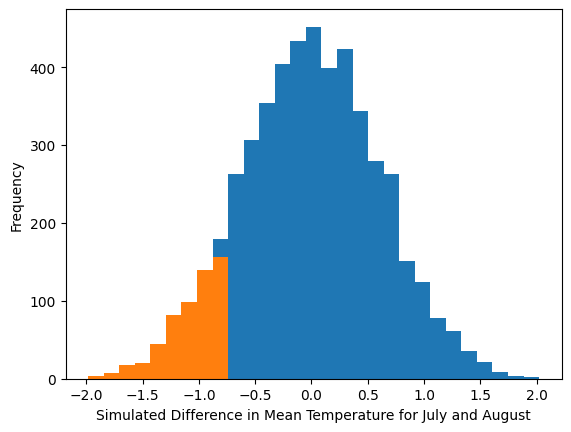

In [4]:
# -----------------------------
# STEP 5: INTERPRETATION
# -----------------------------
bins = np.linspace(simulated_diffs.min(),
                   simulated_diffs.max(),
                   30)


if observed_diff > 0:
  p_value = np.mean(simulated_diffs >= observed_diff)
  count = np.sum(simulated_diffs >= observed_diff)
  plt.hist(simulated_diffs, bins=bins)

  plt.hist(
      simulated_diffs[simulated_diffs >= observed_diff],
      bins=bins)
  plt.xlabel(f"Simulated Difference in Mean Temperature for {month1text} and {month2text}")
  plt.ylabel("Frequency")

if observed_diff < 0:
  p_value = np.mean(simulated_diffs <= observed_diff)
  count = np.sum(simulated_diffs <= observed_diff)
  plt.hist(simulated_diffs, bins=bins)

  plt.hist(
      simulated_diffs[simulated_diffs <= observed_diff],
      bins=bins)

  plt.xlabel(f"Simulated Difference in Mean Temperature for {month1text} and {month2text}")
  plt.ylabel("Frequency")




direction = "greater" if observed_diff > 0 else "less"

if p_value >= 0.05:

    conclusion = (
        f"In our simulations, a result of {observed_diff:.2f} or {direction} "
        f"occurred {count} times in {num_simulations} samples "
        f"(p-value = {p_value:.4f}). Since this result is not unusual "
        f"when assuming {month1text} and {month2text} have the same average "
        f"maximum temperature, there is not convincing evidence against "
        f"the null hypothesis. The difference in means is not statistically significant."
    )

else:

    conclusion = (
        f"In our simulations, a result of {observed_diff:.2f} or {direction} "
        f"occurred only {count} times in {num_simulations} samples "
        f"(p-value = {p_value:.4f}). Since this result is unusual "
        f"when assuming {month1text} and {month2text} have the same average "
        f"maximum temperature, there is convincing evidence against "
        f"the null hypothesis. The difference in means is statistically significant."
    )

import textwrap

print(textwrap.fill(conclusion, width=80))

In [5]:
import numpy as np
import plotly.graph_objects as go
import textwrap

# -----------------------------
# STEP 5: INTERPRETATION
# -----------------------------

bins = np.linspace(
    simulated_diffs.min(),
    simulated_diffs.max(),
    30
)

# Determine tail + p-value
if observed_diff > 0:
    mask = simulated_diffs >= observed_diff
    direction = "greater"
else:
    mask = simulated_diffs <= observed_diff
    direction = "less"

p_value = np.mean(mask)
count = np.sum(mask)

# Create histogram traces
fig = go.Figure()

# Full distribution
fig.add_trace(
    go.Histogram(
        x=simulated_diffs,
        xbins=dict(
            start=bins.min(),
            end=bins.max(),
            size=bins[1] - bins[0]
        ),
        name="All Simulations",
        opacity=0.75
    )
)

# Highlight extreme values
fig.add_trace(
    go.Histogram(
        x=simulated_diffs[mask],
        xbins=dict(
            start=bins.min(),
            end=bins.max(),
            size=bins[1] - bins[0]
        ),
        name="Extreme Simulations",
        opacity=0.9
    )
)

# Observed statistic line
fig.add_vline(
    x=observed_diff,
    line_width=3,
    line_dash="dash",
    annotation_text=f"Observed = {observed_diff:.2f}",
    annotation_position="top"
)

# Layout
fig.update_layout(
    title=f"Simulation Distribution: {month1text} vs {month2text}",
    xaxis_title=(
        f"Simulated Difference in Mean Temperature "
        f"for {month1text} and {month2text}"
    ),
    yaxis_title="Frequency",
    barmode="overlay",
    template="plotly_white"
)

fig.show()

# -----------------------------
# INTERPRETATION TEXT
# -----------------------------

if p_value >= 0.05:

    conclusion = (
        f"In our simulations, a result of {observed_diff:.2f} or "
        f"{direction} occurred {count} times in "
        f"{num_simulations} samples (p-value = {p_value:.4f}). "
        f"Since this result is not unusual when assuming "
        f"{month1text} and {month2text} have the same average "
        f"maximum temperature, there is not convincing evidence "
        f"against the null hypothesis. The difference in means "
        f"is not statistically significant."
    )

else:

    conclusion = (
        f"In our simulations, a result of {observed_diff:.2f} or "
        f"{direction} occurred only {count} times in "
        f"{num_simulations} samples (p-value = {p_value:.4f}). "
        f"Since this result is unusual when assuming "
        f"{month1text} and {month2text} have the same average "
        f"maximum temperature, there is convincing evidence "
        f"against the null hypothesis. The difference in means "
        f"is statistically significant."
    )

print(textwrap.fill(conclusion, width=80))

In our simulations, a result of -0.76 or less occurred 568 times in 5000 samples
(p-value = 0.1136). Since this result is not unusual when assuming July and
August have the same average maximum temperature, there is not convincing
evidence against the null hypothesis. The difference in means is not
statistically significant.


In [7]:
from itertools import combinations
import numpy as np
import pandas as pd

def run_month_test(df, mo1, mo2, num_simulations=5000):
    month1text = pd.to_datetime(f"2026-{mo1:02d}-01").strftime("%B")
    month2text = pd.to_datetime(f"2026-{mo2:02d}-01").strftime("%B")

    month1 = df[df["month"] == mo1]["temperature_2m_max"].values
    month2 = df[df["month"] == mo2]["temperature_2m_max"].values

    observed_diff = month1.mean() - month2.mean()

    combined = np.concatenate([month1, month2])
    simulated_diffs = []

    for i in range(num_simulations):
        shuffled = np.random.permutation(combined)

        sim_mo1 = shuffled[:len(month1)]
        sim_mo2 = shuffled[len(month1):]

        simulated_diffs.append(sim_mo1.mean() - sim_mo2.mean())

    simulated_diffs = np.array(simulated_diffs)

    if observed_diff > 0:
        count = np.sum(simulated_diffs >= observed_diff)
        direction = "greater"
    else:
        count = np.sum(simulated_diffs <= observed_diff)
        direction = "less"

    p_value = count / num_simulations

    conclusion = (
        f"{month1text} vs {month2text}: A result of {observed_diff:.2f} or {direction} "
        f"occurred {count} times in {num_simulations} simulations "
        f"(p-value = {p_value:.4f}). "
    )

    if p_value < 0.05:
        conclusion += "The difference in means is statistically significant."
    else:
        conclusion += "The difference in means is not statistically significant."

    return {
        "month1": month1text,
        "month2": month2text,
        "observed_diff": observed_diff,
        "p_value": p_value,
        "count": count,
        "significant": p_value < 0.05,
        "conclusion": conclusion
    }

In [8]:
df["time"] = pd.to_datetime(df["time"])
df["month"] = df["time"].dt.month

results = []

for mo1, mo2 in combinations(range(1, 13), 2):
    results.append(run_month_test(df, mo1, mo2))

results_df = pd.DataFrame(results)

results_df

,month1,month2,observed_diff,p_value,count,significant,conclusion
0,January,February,0.982759,0.0662,331,False,January vs February: A result of 0.98 or great...
1,January,March,-0.977419,0.0642,321,False,January vs March: A result of -0.98 or less oc...
2,January,April,-4.376667,0.0000,0,True,January vs April: A result of -4.38 or less oc...
3,January,May,-5.477419,0.0000,0,True,January vs May: A result of -5.48 or less occu...
4,January,June,-10.086667,0.0000,0,True,January vs June: A result of -10.09 or less oc...
...,...,...,...,...,...,...,...
61,September,November,8.556667,0.0000,0,True,September vs November: A result of 8.56 or gre...
62,September,December,10.341290,0.0000,0,True,September vs December: A result of 10.34 or gr...
63,October,November,6.470215,0.0000,0,True,October vs November: A result of 6.47 or great...
64,October,December,8.254839,0.0000,0,True,October vs December: A result of 8.25 or great...


In [9]:
# Create month-by-month p-value matrix

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

# Empty 12x12 matrix
p_matrix = pd.DataFrame(
    np.nan,
    index=month_names,
    columns=month_names
)

# Fill matrix
for result in results:

    mo1 = pd.to_datetime(result["month1"], format="%B").month
    mo2 = pd.to_datetime(result["month2"], format="%B").month

    p = result["p_value"]

    p_matrix.iloc[mo1 - 1, mo2 - 1] = p
    p_matrix.iloc[mo2 - 1, mo1 - 1] = p

# Optional: set diagonal to 0
np.fill_diagonal(p_matrix.values, 0)

# Round for readability
p_matrix = p_matrix.round(4)

p_matrix

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Jan,0.0000,0.0662,0.0642,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0002
Feb,0.0662,0.0000,0.0002,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Mar,0.0642,0.0002,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0038
Apr,0.0000,0.0000,0.0000,0.0000,0.0732,0.0000,0.0000,0.0000,0.0000,0.0000,0.4336,0.0370
May,0.0000,0.0000,0.0000,0.0732,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0566,0.0000
Jun,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0112,0.1238,0.0000,0.0000
Jul,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1178,0.2604,0.0002,0.0000,0.0000
Aug,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1178,0.0000,0.1156,0.0000,0.0000,0.0000
Sep,0.0000,0.0000,0.0000,0.0000,0.0000,0.0112,0.2604,0.1156,0.0000,0.0640,0.0000,0.0000
Oct,0.0000,0.0000,0.0000,0.0000,0.0000,0.1238,0.0002,0.0000,0.0640,0.0000,0.0000,0.0000


In [10]:
import numpy as np
import pandas as pd
import plotly.express as px

# Keep only upper triangle
upper_matrix = p_matrix.copy()

upper_matrix.values[np.tril_indices_from(upper_matrix, k=-1)] = np.nan

fig = px.imshow(
    upper_matrix,
    text_auto=".4f",
    color_continuous_scale="RdBu_r",
    aspect="auto",
    zmin=0,
    zmax=1,
)

fig.update_layout(
    title="Month-by-Month P-Value Matrix (Upper Triangle)",
    xaxis_title="Month",
    yaxis_title="Month",
)

fig.update_xaxes(side="top")

fig.show()